In [5]:
!pip install gensim

In [6]:
import tensorflow as tf
import gensim.downloader as api
import re
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec
import numpy as np


In [7]:
texts = [
    "I love this product.",
    "This movie is amazing.",
    "The food was delicious.",
    "I am very happy today.",
    "The service was excellent.",
    "I hate this product.",
    "This movie is boring.",
    "The food was terrible.",
    "I am very sad today.",
    "The service was bad.",
    "The sandwich was good but noodles were tasty"
]

labels = np.array([1,1,1,1,1,0,0,0,0,0,1])


In [8]:
tokens = []
for i in texts:
    i = i.lower()
    i = re.sub(r"[^a-zA-Z\s]", "", i)
    words = i.split()
    tokens.append(words)

print(tokens)

[['i', 'love', 'this', 'product'], ['this', 'movie', 'is', 'amazing'], ['the', 'food', 'was', 'delicious'], ['i', 'am', 'very', 'happy', 'today'], ['the', 'service', 'was', 'excellent'], ['i', 'hate', 'this', 'product'], ['this', 'movie', 'is', 'boring'], ['the', 'food', 'was', 'terrible'], ['i', 'am', 'very', 'sad', 'today'], ['the', 'service', 'was', 'bad'], ['the', 'sandwich', 'was', 'good', 'but', 'noodles', 'were', 'tasty']]


In [9]:
word_model = Word2Vec(
    sentences=tokens,
    vector_size=50,
    window=2,
    min_count=1,
    workers=1,
    sg=1
)


In [10]:
sentence_vectors = []

for sentence in tokens:
    word_vectors = []

    for word in sentence:
        word_vectors.append(word_model.wv[word])

    sentence_vector = np.mean(word_vectors, axis=0)
    sentence_vectors.append(sentence_vector)

X_word = np.array(sentence_vectors)

print(X_word.shape)

(11, 50)


In [11]:
model2 = Sequential()
model2.add(Dense(8,activation = 'relu', input_shape = (X_word.shape[1],)))
model2.add(Dense(1,activation = 'sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │           408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417 (1.63 KB)

 Trainable params: 417 (1.63 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model2.fit(X_word,labels,epochs=15,verbose=0)
loss, accuracy = model2.evaluate(X_word, labels)

print("Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.5455 - loss: 0.6908
Accuracy: 0.5454545617103577


In [14]:
new_texts = [
    "The noodles were tasty"]

new_tokens = []
for i in new_texts:
    i = i.lower()
    i = re.sub(r"[^a-zA-Z\s]", "", i)
    words = i.split()
    new_tokens.append(words)

print(new_tokens)




[['the', 'noodles', 'were', 'tasty']]


In [15]:
word_model.build_vocab(new_tokens, update=True)

word_model.train(
    new_tokens,
    total_examples=len(new_tokens),
    epochs=15
)

new_sentence_vectors = []

for sentence in new_tokens:
    word_vectors = []

    for word in sentence:
        word_vectors.append(word_model.wv[word])

    new_sentence_vector = np.mean(word_vectors, axis=0)
    new_sentence_vectors.append(new_sentence_vector)

new_word = np.array(new_sentence_vectors)

print(new_word.shape)

(1, 50)


In [16]:
predictions = model2.predict(new_word)
print("Predicted probabilities for new texts:")
print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Predicted probabilities for new texts:
[[0.5071533]]


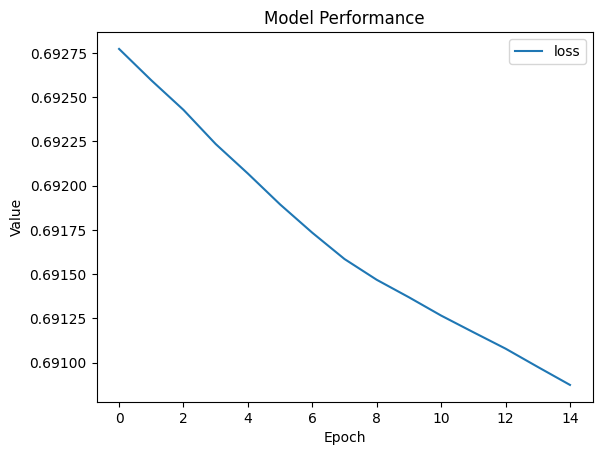

In [17]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='loss')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Model Performance')
plt.legend()
plt.show()